# Welcom to HiPIMS!


This document gives you a guidance and embeds the code to run the hipims code for case study.
You can run this tutorial in a couple of ways:

**In the cloud:** This is an easy way to get started! Use link to opens an integrated notebook in Google Colab.

**Locally:** This option requires you to setup HiPIMS first on your local machine. Download the notebook or copy the code into your favorite IDE. We recommand you using CUDA 12.1 and python 3.10.

## About
HiPIMS names for High-Performance Integrated hydrodynamic Modelling System. It uses state-of-art numerical schemes (Godunov-type finite volume) to solve the 2D shallow water equations for flood simulations. To support high-resolution flood simulations, HiPIMS is implemented on multiple GPUs (Graphics Processing Unit) using CUDA/C++ languages to achieve high-performance computing.

**Package Author:** Xue Tong, Jiaheng Zhao

**Guidance and leadership:** Prof. Qiuhua Liang

**Affiliation:** Loughborough University


## 1. Install and import the package 

### 1.1 Recommended applications:
- [**Visual Studio Code**](https://code.visualstudio.com/download) as Python IDE

- For Windows only:
    - [**Anaconda to manage**](https://docs.anaconda.com/anaconda/install/) Python environment
    - Download Visual Studio 2022 17.9: https://download.visualstudio.microsoft.com/download/pr/7e1f1b8d-73fe-448c-a4e0-0ea481025985/110c25702bb7e40f1c04da43e99afa3d54ee5adf45225908747ac26c1104b60a/vs_BuildTools.exe

### 1.2 Create a environment for HiPIMS
Open a new **Terminal** in VS Code and create a new environment, **do not forget to replace your_env_name**:

In [ ]:
conda update -n base -c defaults conda
conda create --name your_env_name python=3.10
conda activate your_env_name

### 1.3 Check requirements 
- For Windows user only:
    - check if you have a NVIDIA GPU: click in the “Type here to search” box next to the Start button, type “dxdiag”, press Enter, and go to the “Display” tab to see your GPU information.
- NVIDIA driver requirements: CUDA > 12.1
    - ```nvidia-smi ```
    - If it is too old or do not exists, update/install via GeForce Experience Or [Official website](https://www.nvidia.com/en-us/drivers/).
- Python requirements: 3.10
    - ```python --version ```
    - if not python 3.10: Ctrl + shift + P, select python interpreter, If still cannot find, reinstall Python Extension in VS Code.

### 1.4 Install HiPIMS and nessary packages in Terminal:

In [ ]:
conda install nvidia/label/cuda-12.1.0::cuda
conda install pytorch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 pytorch-cuda=12.1 -c pytorch -c nvidia

In [ ]:
pip install --upgrade pip
pip install hipims

if ```pip install hipims``` not work, try ```python -m pip install hipims``` instead.

### 1.5 Test HiPIMS

In [1]:
from hipims.InputHipims import InputHipims
from hipims import flood
from hipims import visualization as visual

         Welcome to the HiPIMS! 

██╗  ██╗███████╗███╗   ███╗██╗      █████╗ ██████╗ 
██║  ██║██╔════╝████╗ ████║██║     ██╔══██╗██╔══██╗
███████║█████╗  ██╔████╔██║██║     ███████║██████╔╝
██╔══██║██╔══╝  ██║╚██╔╝██║██║     ██╔══██║██╔══██╗
██║  ██║███████╗██║ ╚═╝ ██║███████╗██║  ██║██████╔╝
╚═╝  ╚═╝╚══════╝╚═╝     ╚═╝╚══════╝╚═╝  ╚═╝╚═════╝ 
    ██╗  ██╗██╗██████╗ ██╗███╗   ███╗███████╗      
    ██║  ██║██║██╔══██╗██║████╗ ████║██╔════╝      
    ███████║██║██████╔╝██║██╔████╔██║███████╗      
    ██╔══██║██║██╔═══╝ ██║██║╚██╔╝██║╚════██║      
    ██║  ██║██║██║     ██║██║ ╚═╝ ██║███████║      
    ╚═╝  ╚═╝╚═╝╚═╝     ╚═╝╚═╝     ╚═╝╚══════╝      


## 2. Data Formats and Types
To run the flood model, you need to prepare specific data types. Below are the minimum required data and additional **data types** that can enhance your simulations.

1. **Spatial Distribution Data (SDD)**:  
   These data describe spatial patterns and variations across different locations. The supported formats include:  
   - **Single Value**: Represents a uniform value across the entire spatial domain, used when the phenomenon is consistent across all locations.
   - **`np.array` (NumPy Array)**: Allows users to input customised values as an array to represent spatial data.  
     *Note: The shape of the `np.array` must match the shape of the DEM to maintain spatial consistency.*
   - **`tif` (GeoTIFF) File**: A raster data format that includes geographic coordinate information, allowing for detailed spatial modelling.  
     *Note: The grid size of the GeoTIFF file must match that of the DEM.*

2. **Time Series Data (TSD)**:  
   These data represent temporal dynamics and support the following formats:  
   - **Single Value**: Represents a uniform value across the entire time period, implying no variation over time.
   - **`np.array` (NumPy Array)**: Allows users to input customised time series data. The first column represents the time series (unit: seconds), and the subsequent columns contain the corresponding values.
   - **File**: Time series data can be stored in a file, such as a `.txt` or `Excel file`.  
     *Note: If the data are on a specific sheet in an Excel file, use the format `['filename', 'sheetname']`. Otherwise, use `'filename'`.*

## 3. Running HiPIMS for Catchment Case Study
3.1 & 3.9 are necessary. 

3.2-3.8 are optional, call only differ from default.

*Note: SDD refers to Spatial Distribution Data; TSD refers to Time Series Data.*


### 3.1 Quickstart

To define the model case, use the following:

- **Data Requirements**:
  - `DEM.tif` : Digital Elevation Model (DEM), providing terrain elevation data necessary for calculating water flow paths.

- **Function**: `InputHipims`

  **Keyword Arguments**:

<div align="center">

| Argument           | Type    | Description                                                               |
|--------------------|---------|---------------------------------------------------------------------------|
| `case_folder`      | String  | Path to the folder containing the case files.                              |
| `dem_path`         | String  | Path to the Digital Elevation Model (DEM) file, providing terrain data.    |
| `output_folder`    | String  | Path to the folder where the simulation output files will be saved.        |
| `rainfall_source`  | TSD     | Source of the rainfall data.                                               |

</div>


In [2]:
from hipims import get_sample
case_folder, dem_name, output_folder, rainfall_source = get_sample.get_sample_data()
print(case_folder)
print(dem_name)

c:\Users\cvxt2\.conda\envs\py310\lib\site-packages\hipims\sample
DEM.tif


Setting up your own case? Run: (Do not Run if you are using Google Colab!)

In [ ]:
case_folder = r"C:\Users\cvxt2\OneDrive - Loughborough University\HiPIMS_2024\sample"
dem_name = r"depth.tif" 
output_folder = r"C:\Users\cvxt2\OneDrive - Loughborough University\HiPIMS_2024\sample\output" 
rainfall_source = r"C:\Users\cvxt2\OneDrive - Loughborough University\HiPIMS_2024\sample\input\rainfall_source.xlsx"

In [3]:
# minimal requirements
inputs = InputHipims(case_folder = case_folder,
                     dem_path = dem_name,
                     output_folder= output_folder,
                     rainfall_source = rainfall_source)

Want to see your simulation area? Run:

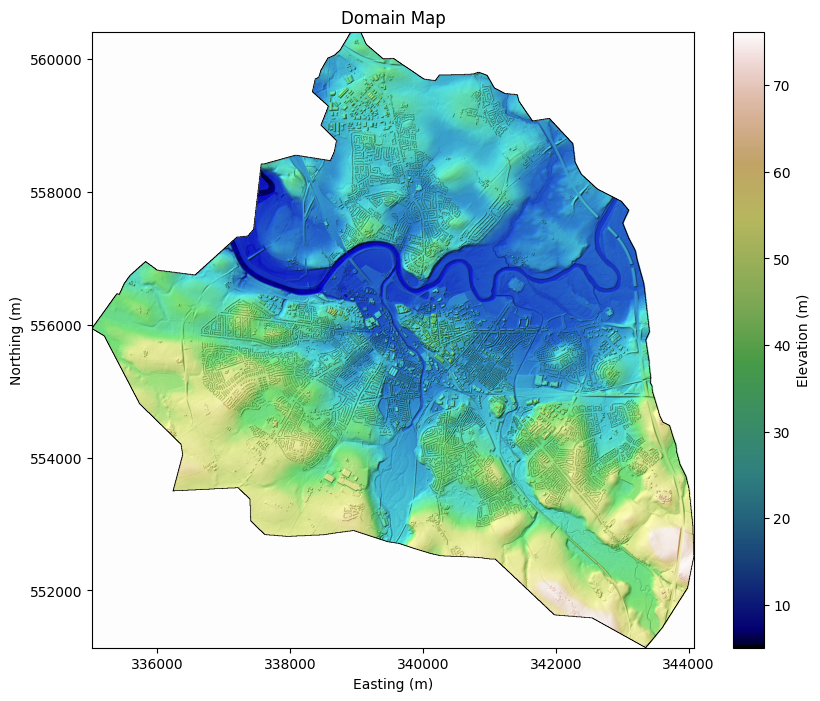

In [4]:
import os
input_folder = os.path.join(case_folder, 'input/')
dem_path = os.path.join(input_folder, dem_name)
outline_path = os.path.join(input_folder, 'outline.shp')
visual.domain(file_path = dem_path, outline=outline_path)

### 3.2. Set Up Model Parameters

Define the model parameters to control the simulation's configuration. 

- **Function**: `set_model_parameters`

  **Keyword Arguments**:

<div align="center">

| Argument              | Type     | Default  | Description                                                            |
|-----------------------|----------|----------|------------------------------------------------------------------------|
| `num_GPU`             | Integer  | `1`      | Number of GPU devices to use.                                          |
| `start_time`          | Numeric  | `0`      | Simulation start time in seconds.                                      |
| `GPU_device_ID`       | Integer  | `0`      | ID of the GPU device.                                                  |
| `end_time`            | Numeric  | `3600`   | Total simulation time in seconds.                                      |
| `output_interval`     | Numeric  | `600`    | Specifies how frequently (in seconds) the output files are saved.      |
| `second_order`        | Boolean  | `False`  | Specifies whether to use a second-order solver.                        |
| `projected_coordinate`| Boolean  | `False`  | Indicates whether the geographic coordinate is in a projected coordinate system.                        |

</div>


In [5]:
inputs.set_model_parameters(output_interval=600, end_time=600)

### 3.3 Set Initial Condition

Define the initial conditions for the simulation. By default, the simulation area is considered completely dry.
- **Function**: `set_initial_condition`

  **Keyword Arguments:**

<div align="center">

| Argument     | Type  | Unit       | Default | Description                                |
|--------------|-------|------------|---------|--------------------------------------------|
| `h0`         | SPD   | Metres (m) | `0`     | Initial water depth.                       |
| `hU0x`       | SPD   | Metres (m) | `0`     | Initial unit discharge in the x-direction. |
| `hU0`        | SPD   | Metres (m) | `0`     | Initial unit discharge in the y-direction. |

</div>



In [6]:
inputs.set_initial_condition(h0='depth.tif',
                              hU0x='hux.tif',
                              hU0y='huy.tif')

Want to see initial condition? Run:

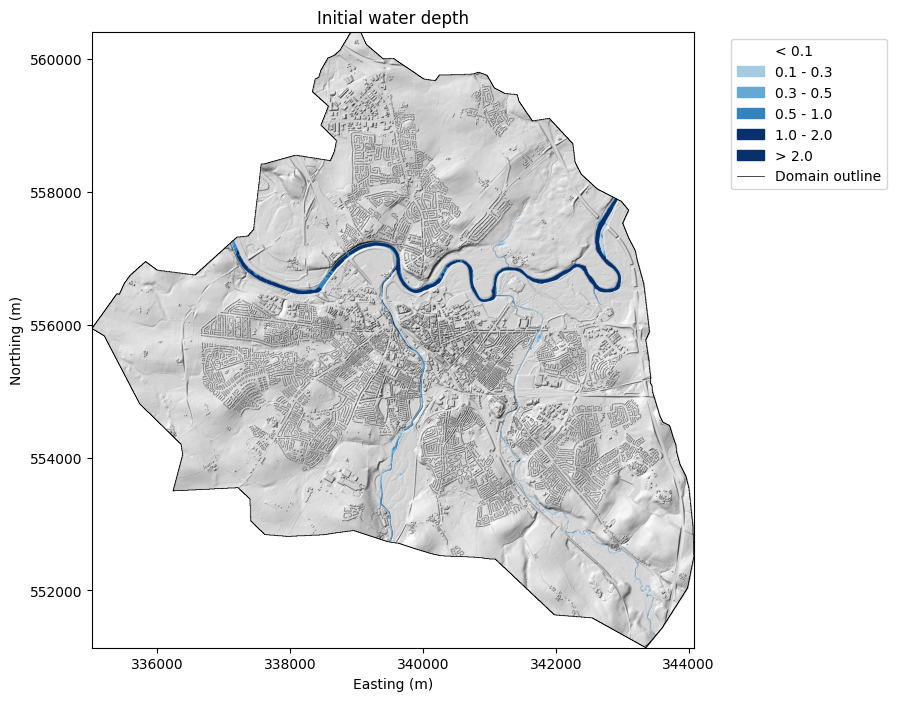

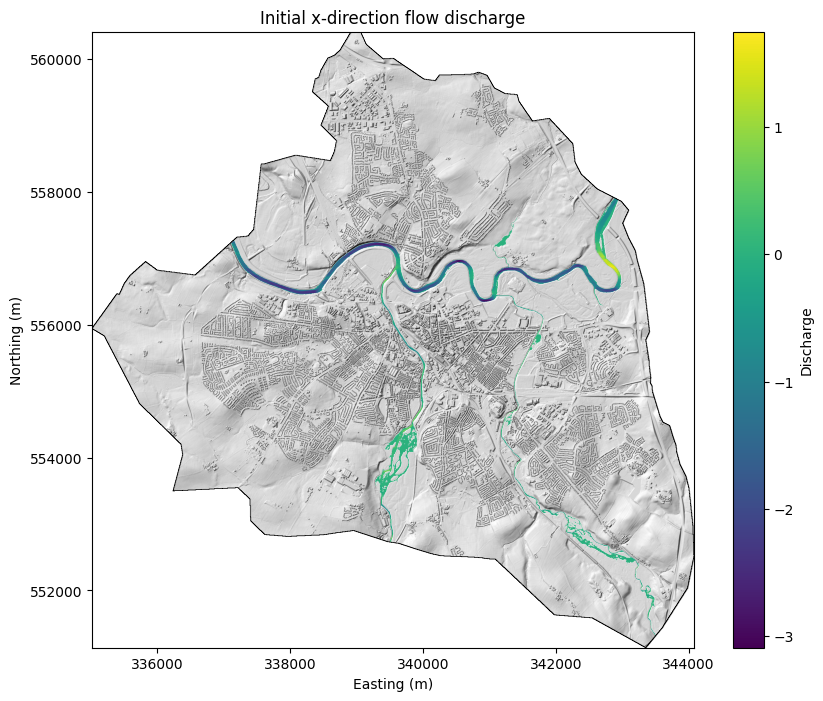

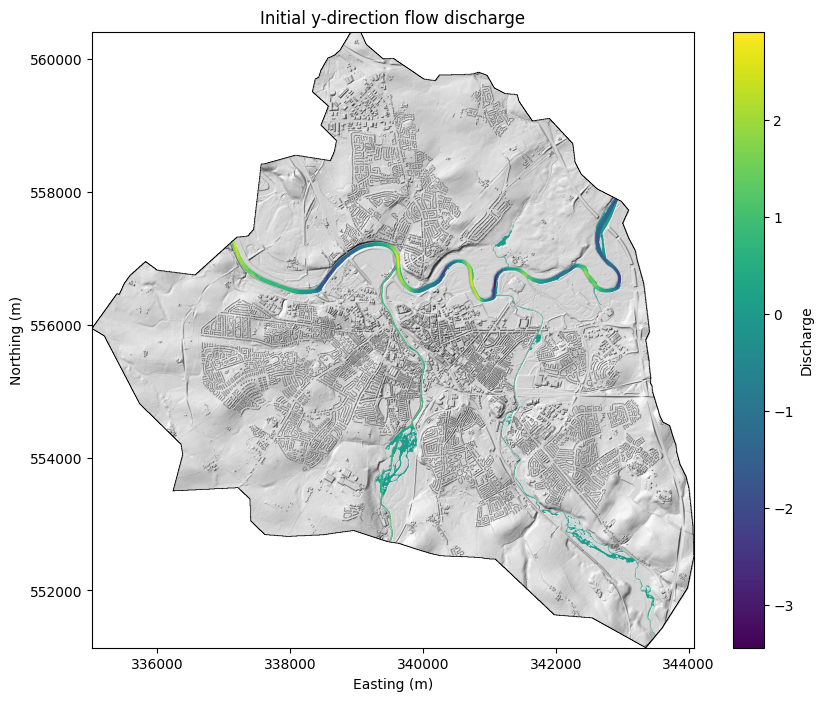

In [7]:
# show initial water depth
depth_path = os.path.join(input_folder, 'depth.tif')
visual.inundation_depth(file_path= depth_path, 
                        title = 'Initial water depth',
                        basemap = dem_path,
                        outline = outline_path)

# show initial discharge in x-direction
hux_path = os.path.join(input_folder, 'hux.tif')
visual.discharge(file_path=hux_path,
                 title = 'Initial x-direction flow discharge',
                 basemap = dem_path,
                 outline = outline_path)

# show initial discharge in y-direction
huy_path = os.path.join(input_folder, 'huy.tif')
visual.discharge(file_path=huy_path,
                 title = 'Initial y-direction flow discharge',
                 basemap = dem_path,
                 outline = outline_path)

### 3.4. Set Rainfall
Define the rainfall data for the simulation. By default, there is no rainfall.

- **Function**: `set_rainfall`

  **Keyword Arguments:**

<div align="center">

| Argument      | Type                             | Unit                     | Default | Description                                                                                           |
|---------------|----------------------------------|--------------------------|---------|-------------------------------------------------------------------------------------------------------|
| `rain_mask`   | SDD   | N/A     | `0`     | A mask that defines the rainfall station indices. indices.                                                     |
| `rain_source` | TSD   | mm/hr   | `0`     | The source of rainfall data. The first column represents time, and the subsequent columns correspond to the indices in `rain_mask`, starting from 0. |

</div>


In [8]:
inputs.set_rainfall(rain_mask='rainMask.tif',rain_source='rainfall_source.txt')

Want to see the rainfall mask and time series? Run:

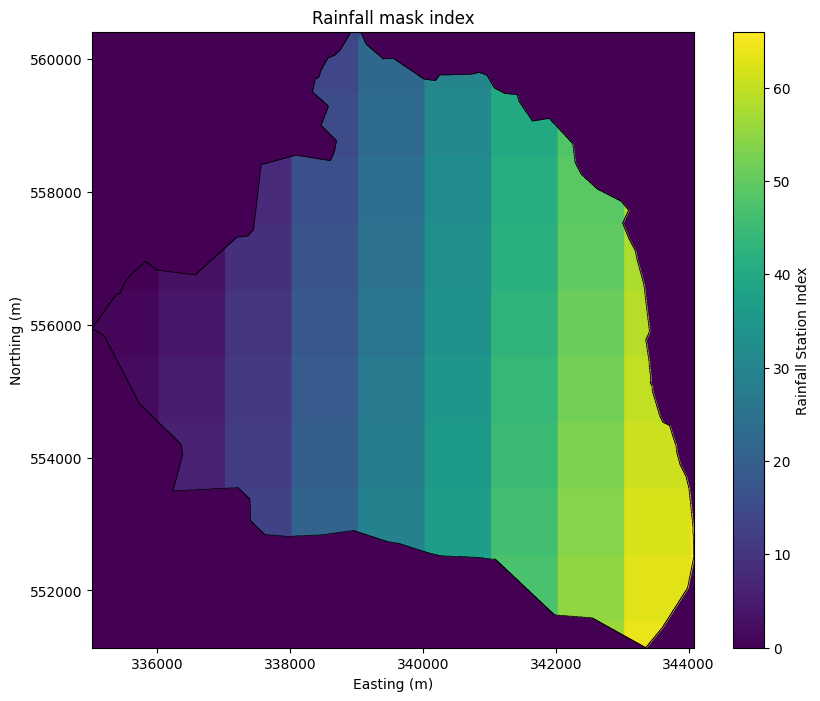

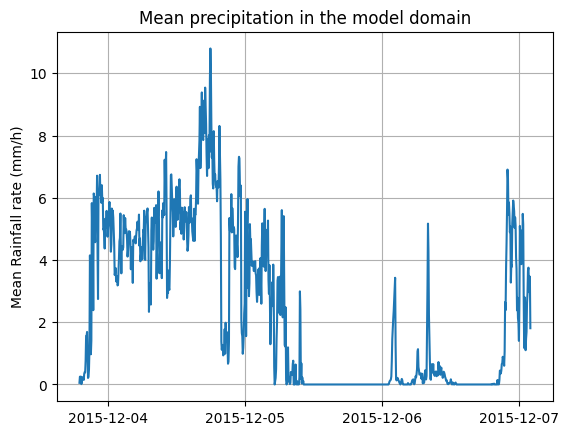

In [9]:
# show the rainfall mask
rain_path = os.path.join(input_folder, 'rainMask.tif')
visual.rain_mask(file_path = rain_path,
                 outline = outline_path)

# show the raifnall time series
from datetime import datetime
rain_source_path = os.path.join(input_folder, 'rainfall_source.txt')
start_date = datetime(2015,12,4,17,0,0)
visual.rainfall_time_series(file_path = rain_source_path,
                            start_date = start_date)

### 3.5. Set Boundary Condition

Define the Input/Output (IO) boundaries at the edges of the model domain. These boundaries typically represent river inflow from upstream or river water depth/tidal levels downstream.

- **Function**: `set_boundary_condition`

  **Keyword Arguments:**

| Argument           | Type                   | Description                                                                                                    |
|--------------------|------------------------|----------------------------------------------------------------------------------------------------------------|
| `bound_list`       | List of dictionaries   | A list where each dictionary represents a boundary condition for the model.                                    |
| - `extent`         | Array                  | Specifies the boundary's spatial extent using minimum and maximum X and Y coordinates in the format `[x_min, x_max, y_min, y_max]`. |
| - `type`           | String                 | Defines the type of boundary condition (see **Boundary Condition Types** below for details).                   |
| - `source`         | TSD / None             | Specifies the source of data for the boundary condition. (see **Boundary Condition Types** below for details). |
| `outline_boundary` | String                 | Specifies the condition applied to the model's outer boundary.                                                 |

- **Boundary Condition Types**

  The following types of boundary conditions are available:

<div align="center">

| Boundary Type   | Description                                                                 | Source | Unit                        |
|-----------------|-----------------------------------------------------------------------------|--------------------------------------|------------------------------|
| `RIGID`         | A solid, non-movable boundary.                                               | None | N/A                          |
| `WALL_SLIP`     | Allows slip conditions along a wall boundary.                                | None | N/A                          |
| `OPEN`          | An open boundary where flow can freely enter or exit.                        | None  | N/A                          |
| `H_GIVEN`       | A boundary with a specified water depth.                                     | TSD          | m                |
| `Q_GIVEN`       | A boundary with a specified flow discharge.                                  | TSD| m³/s|
| `WL_GIVEN`      | A boundary with a specified water level.                                     | TSD| m               |
| `FALL`          | A specific condition, such as a falling water level.                         | None           | N/A |

</div>

In [10]:
boundary1 = {'extent': [339490.05, 339516.74, 552724.15, 552731.72], #[left, right, bottom, top]
             'type': 'WL_GIVEN', 
             'source': 23.8}
boundary2 = {'extent': [343488.09, 343505.57, 551295.62, 551320.47],
             'type': 'Q_GIVEN', 
             'source': ['Q_source.xlsx', 'Petteril']}
boundary3 = {'extent': [342871.50, 342931.40, 557885.14, 557918.513],
             'type': 'Q_GIVEN', 
             'source': ['Q_source.xlsx', 'Eden']}
boundary4 = {'extent':  [337093.251, 337163.418, 557213.469, 557293.638],
             'type': 'OPEN', 
             'source': None}

bound_list = [boundary1, boundary2, boundary3, boundary4 ]

inputs.set_boundary_condition(bound_list = bound_list,
                              outline_boundary = 'FALL')

Show your boundary? Run:

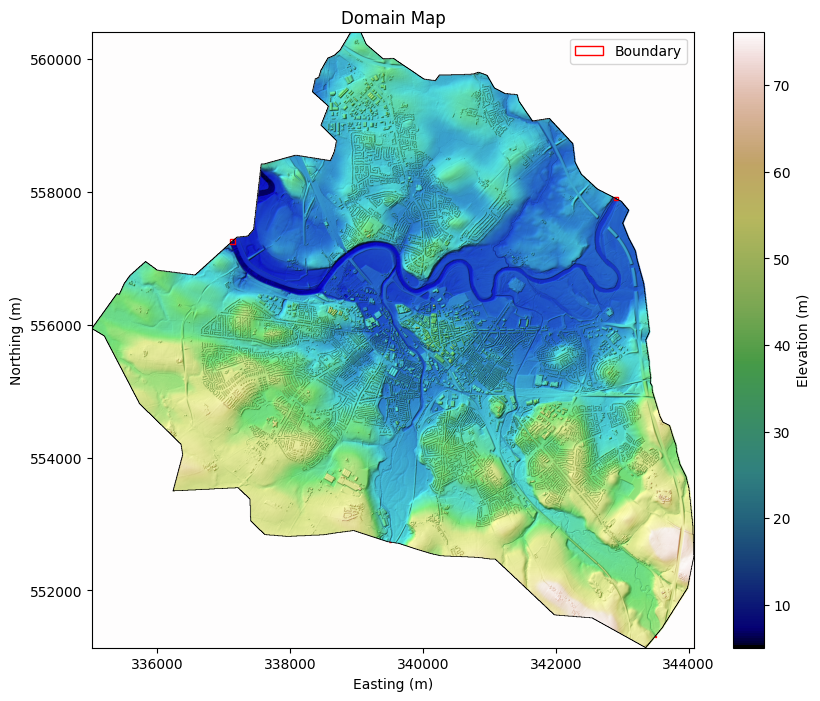

In [11]:
visual.domain(file_path = dem_path, bound_list= bound_list, outline=outline_path)

### 3.6. Land Cover and Related Processes
Land cover types, such as forests, urban areas, or fields, affect the speed and volume of surface water flow by influencing processes like surface friction, infiltration, and sewer drainage.

#### 3.6.1 Defining Land Cover
Define the land cover data for the simulation to represent different types of land use within the case domain.

- **Function**: `set_landuse` 

    **Keyword Argument:**

<div align="center">

| Argument        | Type                             | Default | Description                                                |
|-----------------|----------------------------------|---------|------------------------------------------------------------|
| `landuse_mask`  | SPD (Spatial Distribution Data)  | `0`     | Indexes the land use distribution within the case domain.   |

</div>

In [12]:
inputs.set_landuse(landuse_mask='Landcover.tif')

To show the Landuse data, run:

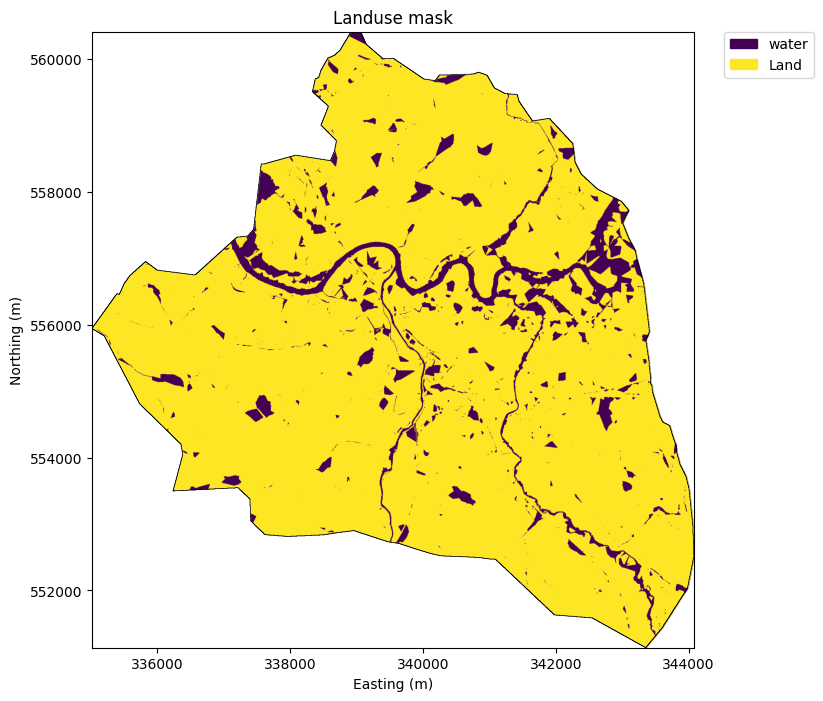

In [13]:
land_path = os.path.join(input_folder, 'Landcover.tif')
visual.land_mask(file_path = land_path, 
                 categories={1:'water', 2:'Land'},
                 title = 'Landuse mask',
                 outline = outline_path)

#### 3.6.2 Common Data Formats for Land Cover-Based Parameters
All land cover-based parameters share the following data formats:
- **Single Value**:  A numeric value applied for all land use categories.
- **`np.array` (NumPy Array)**: An array of numeric values corresponding to the land use categories defined in the `landuse_mask`. The values should be ordered from the smallest to the largest land use indices.
- **List**:  A list format that allows for custom settings:
   - **`'default_value'`**: The default parameter value for all land use categories unless specified otherwise.
   - **`'special_land_type_value'`**: The index of a specific land use category requiring a different parameter value.
   - **`'special_param_value'`**: The value corresponding to the `special_land_type_value` for the specified parameter.

#### 3.6.3 Friction
Friction in hydrodynamic modelling refers to the resistance water encounters as it flows over different surfaces, such as riverbeds, floodplains, or urban landscapes. This resistance is primarily influenced by the roughness of the surface, which slows down the water and dissipates its energy.

- **Function**: `set_manning` 

    **Keyword Argument:**

<div align="center">

| Argument        | Type                             | Default | Description                                                |
|-----------------|----------------------------------|---------|------------------------------------------------------------|
| `manning`  | Land Cover-Based Parameters  | `0`     | The roughness coefficient. Higher values represent rougher surfaces, slowing down water flow.  |

</div>


In [14]:
inputs.set_manning(manning={'default_value': 0.035,
                            'special_land_type_value': [1],
                            'special_param_value': [0.03]})

#### 3.6.4 Infiltration

Infiltration is the process by which water on the ground surface enters the soil. In HiPIMS, the [**Green-Ampt model**](https://en.wikipedia.org/wiki/Green%E2%80%93Ampt_model) is used to calculate the amount of water that infiltrates into the soil over time.

There are two methods for setting up infiltration. 

***!!! Run one of the following methods depending on your own case:***



##### Method 1: Manual Parameter Setting
Directly assign specific values for each parameter based on different land cover types.

- **Function**: `set_infiltration`

**Keyword Arguments:**

<div align="center">

| Argument                 | Type                         | Default | Description                                                                 |
|--------------------------|------------------------------|---------|-----------------------------------------------------------------------------|
| `cumulative_depth`       | Land Cover-Based Parameters  | `0`     | Cumulative infiltration depth since the start of the simulation (m).         |
| `hydraulic_conductivity` | Land Cover-Based Parameters  | `0`     | The rate at which water moves through the soil, depending on soil properties (m/s). |
| `capillary_head`         | Land Cover-Based Parameters  | `0`     | Soil suction at the wetting front, affecting water infiltration (m).         |
| `water_content_diff`     | Land Cover-Based Parameters  | `0`     | Difference in water content between saturated and initial conditions (m³/m³). |

</div>

In [15]:
inputs.set_infiltration(cumulative_depth=0, 
                        hydraulic_conductivity=0,
                        capillary_head=0,
                        water_content_diff=0)


##### Method 2: Automatic Parameter Setting by Soil Type
Automatically determine parameter values based on the soil type associated with each land cover type.

Soil types are based on the USDA Soil Classification: Clay, Silty Clay, Sandy Clay, Clay Loam, Silty Clay Loam, Sandy Clay Loam, Silt Loam, Loam, Sandy Loam, Loamy Sand, Sand, Impervious Surface, Water.

- **Function**: `set_soil_type`

    **Keyword Arguments:**

<div align="center">

| Argument | Format | Description |
|----------|--------|-------------|
| `soil_type`   | List | Specifies the soil type settings for different land use categories.     |
| - `default_soil_type` | String | Default soil type for all land use categories unless specified otherwise. |
| - `special_land_type_value` | list of values / None | Index of a specific land use category requiring a different soil type.|
| - `special_soil_type` | list of string / None | The soil type corresponding to the `special_land_type_value`.|
</div>



In [ ]:
inputs.set_soil_type(soil_type={'default_soil_type': 'Impervious Surface',
                                'special_land_type_value': [1],
                                'special_soil_type': ['Water']})

#### 3.6.5 Sewer System
By defining areas in the model that drain water into the sewer system, users can simulate how water is removed from specific land cover types, such as roads, at a controlled rate.

- **Function**: `set_sewer_sink`

    **Keyword Arguments:**

<div align="center">

| Argument     | Type                        | Default | Description                                                               |
|--------------|-----------------------------|---------|---------------------------------------------------------------------------|
| `sewer_sink` | Land Cover-Based Parameters | `0`     | Specifies the rate at which water is drained into the sewer system (m/s). |

</div>


In [16]:
inputs.set_sewer_sink(sewer_rate=0)

### 3.7 Set river gauges
Set gauges with the river channel to monitor timeseries of water level and velocity

In [17]:
import numpy as np
gauge_coords = np.array([[340194, 556641]])
inputs.set_gauges_position(gauge_coords)

### 3.8. Check your data before running

In [18]:
print(inputs)

---------------------- Case Information ---------------------
* To change paramaeters, use the 'set_case_info' function. For details, visit http_path
case_folder: c:\Users\cvxt2\.conda\envs\py310\lib\site-packages\hipims\sample
input_folder: c:\Users\cvxt2\.conda\envs\py310\lib\site-packages\hipims\sample\input
output_folder: c:\Users\cvxt2\.conda\envs\py310\lib\site-packages\hipims\sample\output
DEM_path: c:\Users\cvxt2\.conda\envs\py310\lib\site-packages\hipims\sample\input\DEM.tif


---------------------- Model Parameters ---------------------
* To change paramaeters, use the 'set_model_parameters' function. For details, visit http_path
num_GPU: 1
start_time: 0
GPU_device_ID: 0
end_time: 600
output_interval: 600
num_gauges: 0
second_order: False
projected_coordinate: False


---------------------- Initial Condition ---------------------
* To change paramaeters, use the 'set_initial_condition' function. For details, visit http_path
h0: c:\Users\cvxt2\.conda\envs\py310\lib\site-packag

### 3.9 Run flood model

The simulation speed may vary depends on the GPU type, grid cell numbers, and the complexity of the simulation case. In this demonstration, it may take you around 20 minutes on Google Colab.

In [19]:
flood.run(inputs)

Initializing data ...
0.384
0.769
1.153
1.538
1.922
2.307
2.691
3.075
3.460
3.844
4.228
4.613
4.997
5.381
5.765
6.149
6.534
6.918
7.302
7.686
8.070
8.454
8.838
9.222
9.606
9.990
10.374
10.758
11.142
11.526
11.909
12.293
12.677
13.061
13.444
13.828
14.212
14.595
14.979
15.363
15.746
16.130
16.513
16.897
17.280
17.664
18.047
18.430
18.814
19.197
19.580
19.964
20.347
20.730
21.114
21.497
21.880
22.263
22.646
23.029
23.413
23.796
24.179
24.562
24.945
25.328
25.711
26.094
26.477
26.860
27.242
27.625
28.008
28.391
28.774
29.157
29.539
29.922
30.305
30.688
31.070
31.453
31.836
32.218
32.601
32.983
33.366
33.748
34.131
34.513
34.896
35.278
35.661
36.043
36.425
36.808
37.190
37.572
37.955
38.337
38.719
39.101
39.484
39.866
40.248
40.630
41.012
41.394
41.776
42.158
42.540
42.922
43.304
43.686
44.068
44.450
44.832
45.214
45.595
45.977
46.359
46.741
47.123
47.504
47.886
48.268
48.649
49.031
49.413
49.794
50.176
50.557
50.939
51.321
51.702
52.084
52.465
52.846
53.228
53.609
53.991
54.372
54.753
55.

## 4. Visualize outputs

Show the maximum water depth within the simulated period. Run:

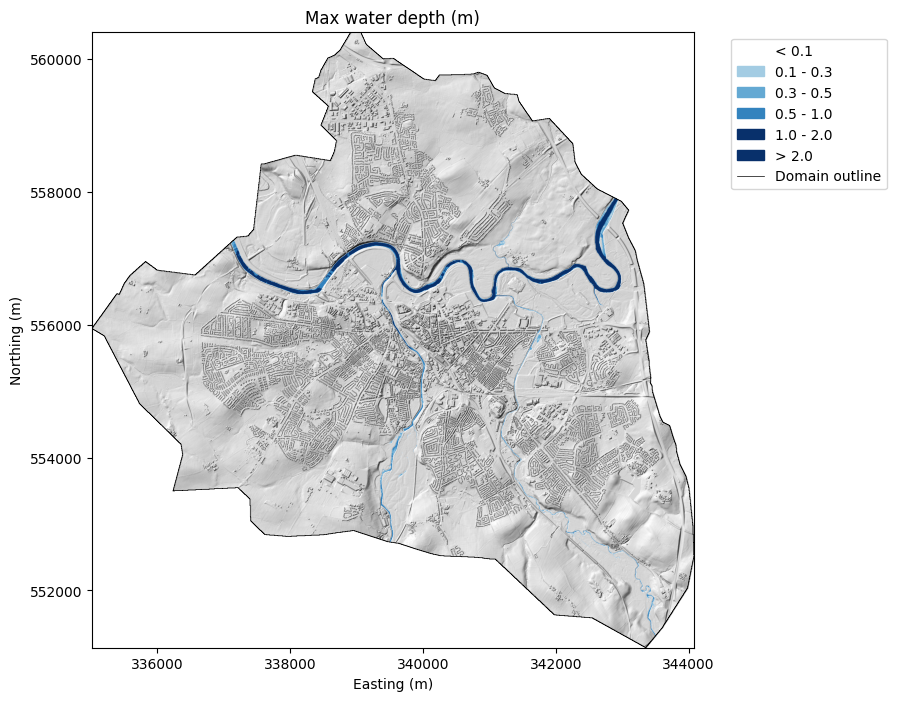

In [20]:
output_folder = os.path.join(case_folder, 'output')

max_depth_path = os.path.join(output_folder, "h_600.tif")

visual.inundation_depth(file_path = max_depth_path,
                        title = 'Max water depth (m)', 
                        basemap=dem_path,
                        outline=outline_path)

### Flood risk assessment
There are lots of method to assess flood risk using HiPIMS outputs. Here we provide an easy demonstration, but you can use your own methods.

Step 1: Choose the key infrastructure. Here schools​ are selected as the critical infrastructure of interest.

Step 2: Use QGIS/ArcGIS tool (such as Zonal Statistics) to figure out maximum inundation depth (denoted as H) within school (or buffer) areas​.

​Step 3: Calculate economic loss of each school area in terms of the economic loss curve. For example F=11616.4*lgH+4030.7* (lgH)2+969.4 *(lgH)3 +30139.1​

​Step 4: Calculate the total expected economic loss of schools​.